In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
df = pd.read_csv("C:/Users/VIHANGI/Downloads/CODVEDA/Data Set For Task-20260609T145424Z-3-001/Data Set For Task/2) Stock Prices Data Set.csv")

df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [9]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

print("\nFirst five rows:")
display(df.head())

Dataset shape:
(497472, 7)

Column names:
Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB

First five rows:


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [10]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64


In [11]:
#Select the required variables and remove missing values

# Select only the opening price and closing price columns
regression_data = df[['open', 'close']].copy()

# Remove rows containing missing values
regression_data = regression_data.dropna()

print("Missing values after cleaning:")
print(regression_data.isnull().sum())

print("\nNumber of rows after cleaning:")
print(regression_data.shape[0])

Missing values after cleaning:
open     0
close    0
dtype: int64

Number of rows after cleaning:
497461


In [12]:
#Define the independent and dependent variables

# Independent variable
X = regression_data[['open']]

# Dependent variable
y = regression_data['close']

In [13]:
#Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data size:", X_train.shape[0])
print("Testing data size:", X_test.shape[0])

Training data size: 397968
Testing data size: 99493


In [14]:
#Create and train the Linear Regression model
model = LinearRegression()

model.fit(X_train, y_train)

print("The Linear Regression model was trained successfully.")

The Linear Regression model was trained successfully.


In [15]:
#Make predictions using the testing data
y_pred = model.predict(X_test)

print("First five predicted closing prices:")
print(y_pred[:5])

First five predicted closing prices:
[524.96078906  70.5278284   82.46632991 759.98128985  28.43311203]


In [16]:
#Display the actual and predicted values
results = pd.DataFrame({
    'Opening Price': X_test['open'].values,
    'Actual Closing Price': y_test.values,
    'Predicted Closing Price': y_pred
})

results.head(10)

,Opening Price,Actual Closing Price,Predicted Closing Price
0,525.00,525.88,524.960789
1,70.51,70.49,70.527828
2,82.45,81.70,82.466330
3,760.05,769.00,759.981290
4,28.41,29.62,28.433112
5,68.88,67.80,68.898033
6,39.64,39.40,39.661703
7,42.39,42.66,42.411358
8,64.45,62.96,64.468589
9,75.01,74.72,75.027264


In [17]:
#Evaluate the model

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared Score:", r2)

Mean Squared Error: 2.7260823685319755
Root Mean Squared Error: 1.651085209349286
R-squared Score: 0.9997383343436389


In [18]:
#Display the coefficient and intercept

intercept = model.intercept_
coefficient = model.coef_[0]

print("Intercept:", intercept)
print("Coefficient:", coefficient)

Intercept: 0.026677540332528338
Coefficient: 0.9998744981397062


In [19]:
#Display the regression equation

print(
    f"Regression Equation: Closing Price = "
    f"{intercept:.4f} + ({coefficient:.4f} × Opening Price)"
)

Regression Equation: Closing Price = 0.0267 + (0.9999 × Opening Price)


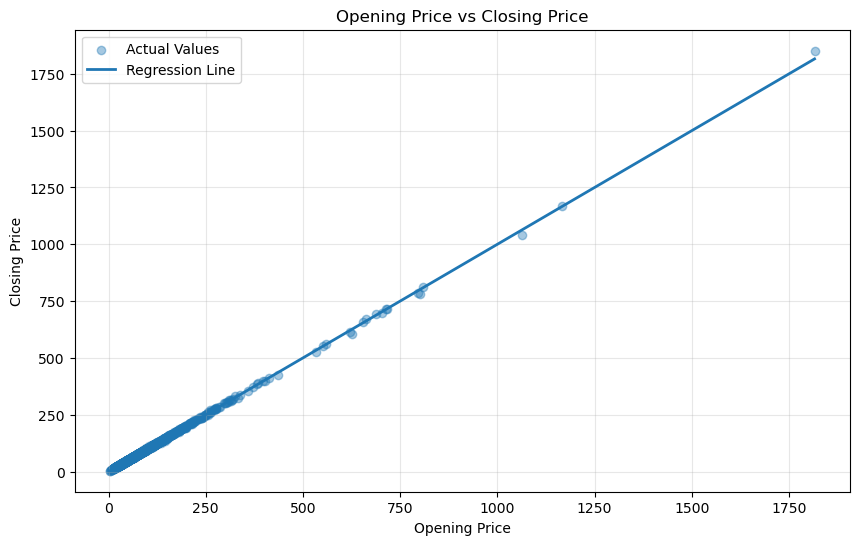

In [20]:
#Create the regression plot

# Create a sample for visualization
plot_data = results.sample(
    n=min(2000, len(results)),
    random_state=42
)

# Sort the values to draw a clear regression line
plot_data = plot_data.sort_values('Opening Price')

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data['Opening Price'],
    plot_data['Actual Closing Price'],
    alpha=0.4,
    label='Actual Values'
)

plt.plot(
    plot_data['Opening Price'],
    plot_data['Predicted Closing Price'],
    linewidth=2,
    label='Regression Line'
)

plt.xlabel("Opening Price")
plt.ylabel("Closing Price")
plt.title("Opening Price vs Closing Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

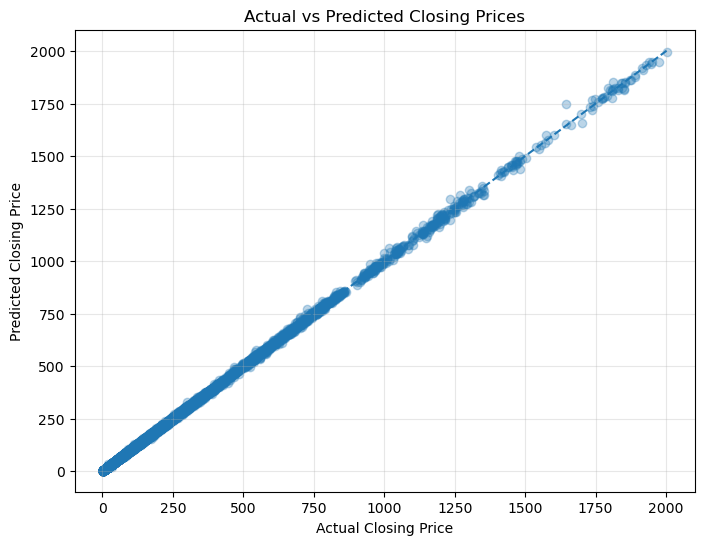

In [21]:
#Plot actual values against predicted values

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

minimum_value = min(y_test.min(), y_pred.min())
maximum_value = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle='--'
)

plt.xlabel("Actual Closing Price")
plt.ylabel("Predicted Closing Price")
plt.title("Actual vs Predicted Closing Prices")
plt.grid(alpha=0.3)
plt.show()

In [24]:
#Save the prediction results

results.to_csv("stock_price_predictions.csv", index=False)

print("Prediction results were saved successfully.")

Prediction results were saved successfully.
